In [3]:
import os
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models

In [9]:
img_height = 224
img_width = 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "images/train",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"   # 2 classes
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "images/test",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 400 files belonging to 5 classes.


Found 150 files belonging to 5 classes.
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Number of classes: 5


In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [6]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)) 


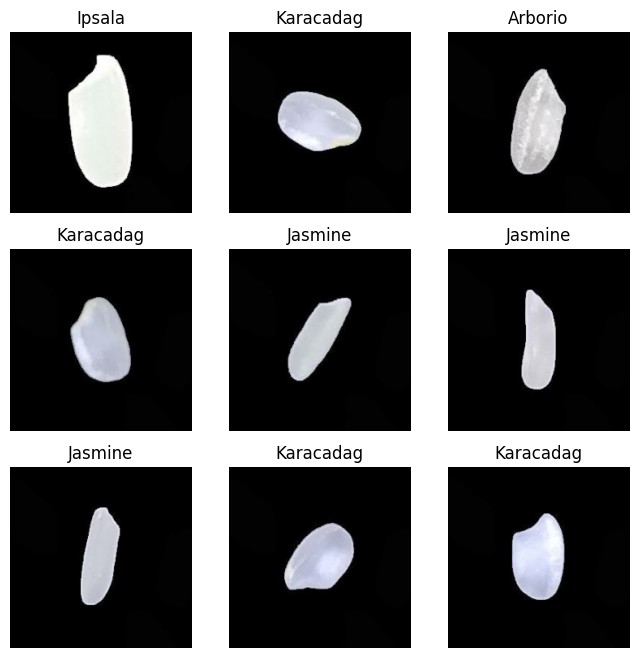

In [7]:
for train_images, train_labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(train_images[i])
        plt.title(class_names[train_labels[i].numpy().argmax()])
        plt.axis("off")
    plt.show()



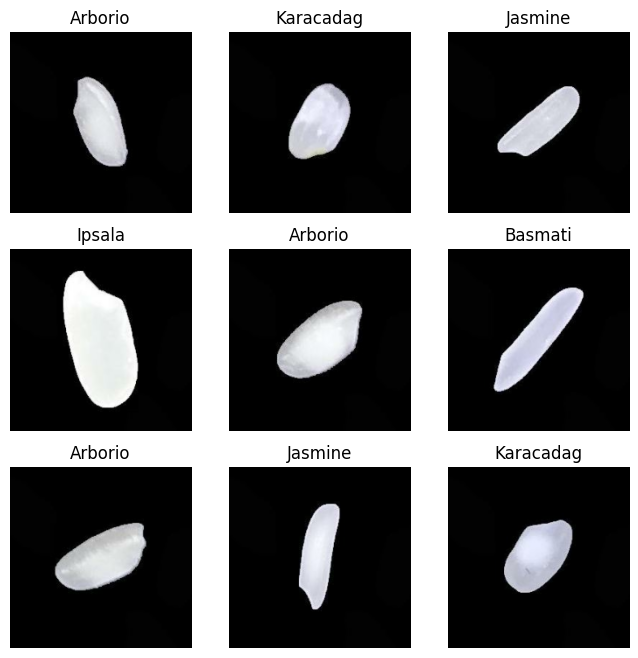

In [8]:
for test_images, test_labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(test_images[i])
        plt.title(class_names[test_labels[i].numpy().argmax()])
        plt.axis("off")
    plt.show()

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),  # 🔥 KEY FIX

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')  # 2 classes
])


In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,357 (110.77 KB)

 Trainable params: 28,357 (110.77 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step - accuracy: 0.1850 - loss: 15.4736 - val_accuracy: 0.2000 - val_loss: 3.3172
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.2225 - loss: 2.1242 - val_accuracy: 0.2067 - val_loss: 1.5481
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - accuracy: 0.2375 - loss: 1.4887 - val_accuracy: 0.4067 - val_loss: 1.4624
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.3775 - loss: 1.4238 - val_accuracy: 0.3400 - val_loss: 1.3973
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step - accuracy: 0.4175 - loss: 1.3674 - val_accuracy: 0.4200 - val_loss: 1.3527
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - accuracy: 0.4325 - loss: 1.3149 - val_accuracy: 0.5867 - val_loss: 1.2815
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.5425 - loss: 1.2336 - val_accuracy: 0.4200 - val_loss: 1.2337
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.5150 - loss: 1.1815 - val_accuracy: 0.5800 - val

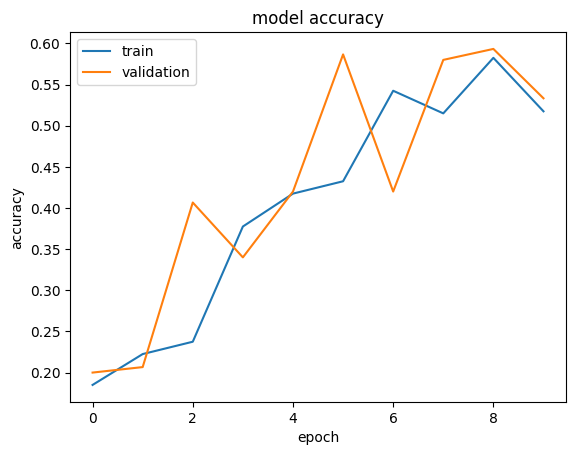

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5333 - loss: 1.0530


In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'])
plt.show()
test_loss, test_acc = model.evaluate(test_ds)


In [ ]:
print(test_acc)

0.5333333611488342
